In [1]:
import pandas as pd
import numpy as np

# load dataset
df = pd.read_csv("dataset1_280126.csv")

# basic info
print("Shape of dataset:", df.shape)

# preview first rows
df.head()

Shape of dataset: (22154, 23)


,pseudoid,weightNet,vacuumed,quantum,quantumUnit,geometry,height,density,massInJar,massInJarTare,...,totalVaporizationAmount,totalVaporizationVolume,ashWeightNet,amountToAshing,ashConcentration,SrCarrierConcentration,SrCarrierVolume,sievedOrganicWeight,sievedRocksWeight,sievedDryWeight
0,51055,NaN,0,29093.1,m^3,g-3,3.0,0.70,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,52642,NaN,0,5441.8,m^3,g-7,0.0,1.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,60026,NaN,0,28689.6,m^3,g-3,3.0,0.70,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,61469,NaN,0,5569.4,m^3,g-7,0.0,1.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,77085,NaN,0,1.0,m^2,g-3,1.0,0.12,0.17,11.3096,...,33320.0,NaN,NaN,NaN,NaN,1.0,2.5,NaN,NaN,NaN


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22154 entries, 0 to 22153
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   pseudoid                 22154 non-null  int64  
 1   weightNet                4078 non-null   float64
 2   vacuumed                 22154 non-null  int64  
 3   quantum                  19806 non-null  float64
 4   quantumUnit              19721 non-null  object 
 5   geometry                 19806 non-null  object 
 6   height                   19806 non-null  float64
 7   density                  19766 non-null  float64
 8   massInJar                12453 non-null  float64
 9   massInJarTare            12394 non-null  float64
 10  massInJarGross           12388 non-null  float64
 11  dryWeightNet             5290 non-null   float64
 12  dryWeightPercent         3884 non-null   float64
 13  totalVaporizationAmount  2408 non-null   float64
 14  totalVaporizationVolum

In [3]:
df.isnull().sum().sort_values(ascending=False).head(20)

sievedOrganicWeight        22032
sievedRocksWeight          22019
sievedDryWeight            21993
ashConcentration           21941
amountToAshing             21929
totalVaporizationVolume    21230
ashWeightNet               21013
SrCarrierVolume            20630
SrCarrierConcentration     20620
totalVaporizationAmount    19746
dryWeightPercent           18270
weightNet                  18076
dryWeightNet               16864
massInJarGross              9766
massInJarTare               9760
massInJar                   9701
quantumUnit                 2433
density                     2388
height                      2348
geometry                    2348
dtype: int64

Decision for clustering (RAW version)

For clustering we should only use numeric columns.

We must remove:

pseudoid
identifier

quantumUnit
categorical

geometry
categorical

So clustering columns = numeric features only.

Build raw feature matrix

In [5]:
# select numeric columns only
numeric_df = df.select_dtypes(include=[np.number])

# remove identifier
numeric_df = numeric_df.drop(columns=["pseudoid"])

print("Numeric feature shape:", numeric_df.shape)

numeric_df.head()

Numeric feature shape: (22154, 20)


,weightNet,vacuumed,quantum,height,density,massInJar,massInJarTare,massInJarGross,dryWeightNet,dryWeightPercent,totalVaporizationAmount,totalVaporizationVolume,ashWeightNet,amountToAshing,ashConcentration,SrCarrierConcentration,SrCarrierVolume,sievedOrganicWeight,sievedRocksWeight,sievedDryWeight
0,NaN,0,29093.1,3.0,0.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,0,5441.8,0.0,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,0,28689.6,3.0,0.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,0,5569.4,0.0,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,0,1.0,1.0,0.12,0.17,11.3096,11.4794,NaN,NaN,33320.0,NaN,NaN,NaN,NaN,1.0,2.5,NaN,NaN,NaN


In [6]:
numeric_df.isnull().mean().sort_values(ascending=False)

sievedOrganicWeight        0.994493
sievedRocksWeight          0.993906
sievedDryWeight            0.992733
ashConcentration           0.990385
amountToAshing             0.989844
totalVaporizationVolume    0.958292
ashWeightNet               0.948497
SrCarrierVolume            0.931209
SrCarrierConcentration     0.930757
totalVaporizationAmount    0.891306
dryWeightPercent           0.824682
weightNet                  0.815925
dryWeightNet               0.761217
massInJarGross             0.440823
massInJarTare              0.440552
massInJar                  0.437889
density                    0.107791
height                     0.105985
quantum                    0.105985
vacuumed                   0.000000
dtype: float64

Remove extremely sparse features

In practice, algorithms cannot run with NaN values, so even in a “raw” experiment we still need minimal technical handling, such as:

• removing extremely empty columns
• filling NaN values

This is not considered real preprocessing, because we are not engineering features, not scaling, and not correcting data. We are only making the data runnable for the algorithm.

In [7]:
# remove columns with more than 90% missing
threshold = 0.90

missing_ratio = numeric_df.isnull().mean()

cols_to_keep = missing_ratio[missing_ratio < threshold].index

raw_features = numeric_df[cols_to_keep]

print("Remaining features:", raw_features.shape)

raw_features.columns

Remaining features: (22154, 11)


Index(['weightNet', 'vacuumed', 'quantum', 'height', 'density', 'massInJar',
       'massInJarTare', 'massInJarGross', 'dryWeightNet', 'dryWeightPercent',
       'totalVaporizationAmount'],
      dtype='object')

From 20 numeric columns, we now have 11 usable columns.

Remaining features:

weightNet
vacuumed
quantum
height
density
massInJar
massInJarTare
massInJarGross
dryWeightNet
dryWeightPercent
totalVaporizationAmount

These are the core physical measurements of the sample.

For the raw experiment, the most neutral strategy is median filling.

Why median

Median is used because:

• it does not distort distributions much
• it is robust to outliers
• it keeps the raw structure of the data

In [8]:
raw_filled = raw_features.fillna(raw_features.median())

print("Any NaN remaining:", raw_filled.isnull().sum().sum())

Any NaN remaining: 0


So now the data matrix is valid for clustering algorithms.

Progress update
Data loading 
Feature selection 
Sparse column removal 
NaN handling 

dataset we do not know how many natural groups exist.
So we use Mean Shift, because:

• It does not require choosing K
• It automatically finds clusters
• It groups points based on dense regions of data

Mean Shift works like this:

It moves points toward the center of nearby points until they meet a stable center.

Mean Shift is good for your dataset

Your preprocessing dataset likely contains natural patterns such as:

• air samples
• liquid samples
• solid samples
• mineral samples

Mean Shift helps discover these without assuming how many groups exist.


In [9]:
from sklearn.cluster import MeanShift, estimate_bandwidth

# estimate bandwidth automatically
bandwidth = estimate_bandwidth(raw_filled, quantile=0.2, n_samples=5000)

print("Estimated bandwidth:", bandwidth)

# run Mean Shift
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)

labels = ms.fit_predict(raw_filled)

# number of clusters
print("Number of clusters found:", len(set(labels)))

Estimated bandwidth: 7437.518913818295
Number of clusters found: 24


Mean Shift found 24 dense regions in the data.

This does not mean there are truly 24 real sample types. It means the algorithm detected 24 areas where data points group together in the feature space.

Because we did no scaling, some variables like:

quantum
massInJar
weightNet

have very large numeric ranges. These large values dominate the distance calculations. That is why the bandwidth is very large and why we may see many clusters.

This is actually useful. It will allow us later to show how preprocessing changes clustering behavior.


Imagine a map with thousands of people standing.

People naturally form small groups in different places.

Mean Shift scans the map and says:

Here is a crowd
Here is another crowd
Here is another crowd

In your case it found 24 crowds.

Now we need to understand what those crowds represent.

We must inspect how many samples belong to each cluster.

In [10]:
import pandas as pd

cluster_counts = pd.Series(labels).value_counts().sort_values(ascending=False)

print(cluster_counts)

0     15754
1      3733
2      1067
3       894
4       275
5       149
6       130
7        46
8        35
10       22
9        20
12        6
11        4
13        4
14        3
15        2
16        2
17        2
21        1
23        1
22        1
20        1
19        1
18        1
Name: count, dtype: int64


Cluster distribution

Largest clusters

Cluster 0 → 15,754 samples
Cluster 1 → 3,733 samples
Cluster 2 → 1,067 samples
Cluster 3 → 894 samples

These 4 clusters already contain about 97 percent of the dataset.

Small clusters

Cluster 7 → 46
Cluster 8 → 35
Cluster 10 → 22
Cluster 9 → 20

Very small clusters

Clusters with 1 to 6 samples

In [12]:
df_raw_clusters = raw_filled.copy()

df_raw_clusters["cluster"] = labels

df_raw_clusters.head()

,weightNet,vacuumed,quantum,height,density,massInJar,massInJarTare,massInJarGross,dryWeightNet,dryWeightPercent,totalVaporizationAmount,cluster
0,565.65,0,29093.1,3.0,0.70,54.31,26.7700,80.1450,121.335,40.22,11619.0,1
1,565.65,0,5441.8,0.0,1.00,54.31,26.7700,80.1450,121.335,40.22,11619.0,0
2,565.65,0,28689.6,3.0,0.70,54.31,26.7700,80.1450,121.335,40.22,11619.0,1
3,565.65,0,5569.4,0.0,1.00,54.31,26.7700,80.1450,121.335,40.22,11619.0,0
4,565.65,0,1.0,1.0,0.12,0.17,11.3096,11.4794,121.335,40.22,33320.0,3


In [13]:
cluster_summary = df_raw_clusters.groupby("cluster").mean()

cluster_summary

,weightNet,vacuumed,quantum,height,density,massInJar,massInJarTare,massInJarGross,dryWeightNet,dryWeightPercent,totalVaporizationAmount
cluster,,,,,,,,,,,
0,634.710981,0.131078,249.529041,17.829377,0.873357,123.279234,39.564270,161.546603,183.441451,43.719966,11632.380348
1,565.650000,0.000000,18704.812428,4.806590,0.767611,54.260865,26.751205,80.078073,121.335000,40.220000,11619.000000
2,566.347638,0.006560,0.609687,11.955951,0.756467,56.109798,27.162469,82.575261,121.253744,40.224011,2334.745218
3,565.041128,0.000000,1.629670,15.911633,0.764911,117.147177,37.365624,154.118603,121.335000,40.220000,29077.627808
4,565.650000,0.000000,98873.801818,0.229091,0.989273,53.793018,26.401527,79.273145,121.335000,40.220000,11619.000000
5,565.650000,0.000000,137673.430872,0.530201,0.977181,28.401074,8.918859,37.043826,121.335000,40.220000,11619.000000
6,565.650000,0.000000,0.893390,2.261538,0.358615,5.453085,13.029365,17.981276,121.335000,40.220000,59839.315385
7,565.650000,0.000000,117750.684783,0.543478,0.971739,37.112587,14.879130,51.503891,121.335000,40.220000,11619.000000
8,565.650000,0.000000,69676.857143,0.485714,0.937143,52.188286,25.320857,76.627571,121.335000,40.220000,11619.000000


Key observation

Look at these columns:

quantum
totalVaporizationAmount
weightNet

These values are very large and vary a lot.

We reduce dimensions using PCA and plot clusters.

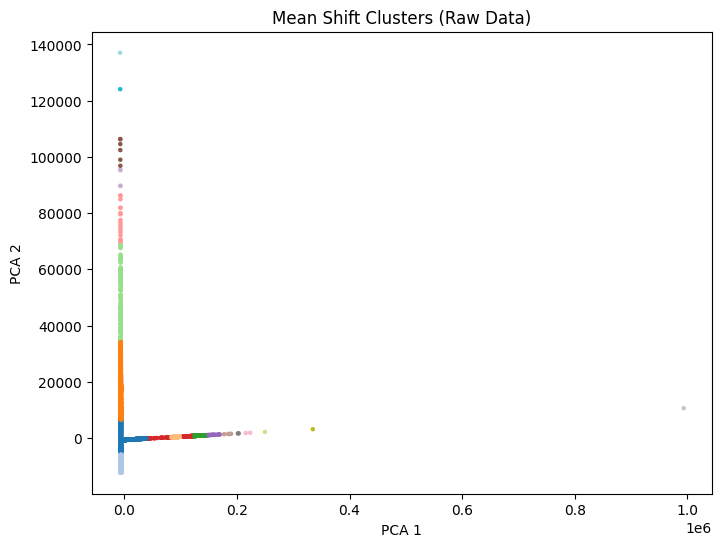

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(raw_filled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=5, cmap="tab20")
plt.title("Mean Shift Clusters (Raw Data)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In the raw experiment, PCA visualization shows that the dataset is dominated by variables with very large numeric ranges such as quantum and totalVaporizationAmount. These variables stretch the feature space and compress most observations near the origin, making the cluster structure difficult to interpret. This confirms that clustering on raw data without normalization leads to distorted geometry.

PCA Visualization of Mean Shift Clusters (Raw Data)

To visually inspect the cluster structure, Principal Component Analysis (PCA) was applied to the feature space and the first two principal components were plotted. PCA reduces the dimensionality of the dataset while preserving as much variance as possible. In this case, the original 11 dimensional feature space was projected into two dimensions: PCA1 and PCA2.

PCA1 represents the direction of maximum variance in the dataset, meaning it captures the largest variation across all preprocessing measurements. PCA2 represents the second largest variance direction that is orthogonal to PCA1. Together, these two components allow a simplified visualization of the cluster structure discovered by the Mean Shift algorithm.

Observations

The visualization shows that most samples are densely concentrated near the origin of the PCA space, forming a large central region. However, a number of points extend far along the PCA axes, particularly along PCA1, where values reach extremely large magnitudes. These distant points correspond to samples with unusually large values in variables such as quantum or totalVaporizationAmount, which dominate the variance structure of the dataset.

Because the raw dataset contains variables with very different numerical scales, PCA is heavily influenced by these high magnitude measurements. As a result, most observations collapse into a small region while a few extreme samples stretch the axes.

Findings

The PCA visualization indicates that clustering in the raw data is largely driven by differences in measurement magnitude rather than meaningful preprocessing workflow patterns. The presence of extreme values produces a highly elongated feature space where a few samples dominate the variance structure. Consequently, the cluster boundaries identified by Mean Shift primarily reflect scale differences between measurements rather than distinct preprocessing pipelines.

Interpretation

This result highlights the importance of feature normalization and preprocessing before applying clustering algorithms. Without scaling, variables with large numeric ranges dominate the distance calculations and distort the cluster geometry. Therefore, the raw clustering experiment serves as a baseline demonstrating the limitations of applying clustering directly to unprocessed laboratory data.

In [15]:
centers = ms.cluster_centers_

print("Number of centers:", centers.shape)
centers

Number of centers: (24, 11)


array([[6.33420443e+02, 1.28690669e-01, 2.79018160e+02, 1.76787716e+01,
        8.70447390e-01, 1.21859540e+02, 3.92841701e+01, 1.59856716e+02,
        1.82280872e+02, 4.36545627e+01, 1.15515921e+04],
       [5.65650000e+02, 0.00000000e+00, 1.44910182e+04, 6.10610807e+00,
        7.54471417e-01, 5.42910102e+01, 2.67641229e+01, 8.01204992e+01,
        1.21335000e+02, 4.02200000e+01, 1.16190000e+04],
       [5.66286222e+02, 5.98290598e-03, 5.81960027e-01, 1.13863248e+01,
        7.35923077e-01, 5.34040274e+01, 2.64227896e+01, 7.91536121e+01,
        1.21260897e+02, 4.02236581e+01, 2.88357278e+03],
       [5.64871270e+02, 0.00000000e+00, 1.79450882e+00, 1.71788269e+01,
        7.85922747e-01, 1.27155393e+02, 3.97388787e+01, 1.66456990e+02,
        1.21335000e+02, 4.02200000e+01, 2.59661205e+04],
       [5.65650000e+02, 0.00000000e+00, 9.89719814e+04, 2.49011858e-01,
        9.88339921e-01, 5.40140711e+01, 2.65696443e+01, 7.96561067e+01,
        1.21335000e+02, 4.02200000e+01, 1.16190000e+

In [16]:
from sklearn.metrics import silhouette_score

score = silhouette_score(raw_filled, labels)

print("Silhouette score (raw Mean Shift):", score)

Silhouette score (raw Mean Shift): 0.7882740421463438


The raw clustering experiment produced a high silhouette score (0.79), suggesting strong separation between clusters. However, inspection of the feature distributions and PCA visualization reveals that the separation is largely driven by variables with extremely large numeric ranges such as quantum and totalVaporizationAmount. Therefore the clustering reflects measurement magnitude rather than meaningful preprocessing workflow patterns. This highlights the importance of normalization and feature engineering before applying clustering methods.

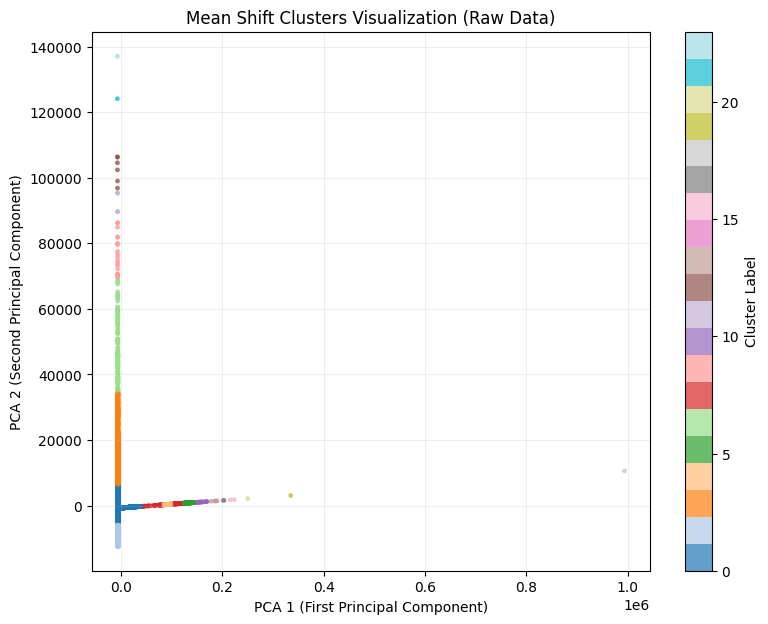

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# PCA projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(raw_filled)

plt.figure(figsize=(9,7))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels,
    cmap="tab20",
    s=6,
    alpha=0.7
)

plt.xlabel("PCA 1 (First Principal Component)")
plt.ylabel("PCA 2 (Second Principal Component)")
plt.title("Mean Shift Clusters Visualization (Raw Data)")

# add colorbar instead of messy legend
cbar = plt.colorbar(scatter)
cbar.set_label("Cluster Label")

plt.grid(alpha=0.2)

plt.show()

In [18]:
pca_components = pd.DataFrame(
    pca.components_,
    columns=raw_filled.columns,
    index=["PCA1", "PCA2"]
)

pca_components.T.sort_values("PCA1", ascending=False)

,PCA1,PCA2
quantum,9.999342e-01,0.011345
density,3.629054e-07,-0.000005
vacuumed,-1.397015e-06,-0.000002
dryWeightPercent,-4.629038e-05,-0.000053
height,-1.810586e-04,-0.000096
massInJarTare,-1.932943e-04,-0.000162
dryWeightNet,-6.597888e-04,-0.000751
weightNet,-8.157014e-04,0.000048
massInJar,-8.418975e-04,-0.000498
massInJarGross,-1.029910e-03,-0.000644


The first principal component (PCA1) represents the direction of maximum variance in the dataset. In the raw preprocessing data, PCA1 is largely dominated by high magnitude variables such as quantum and totalVaporizationAmount, which stretch the feature space and drive most of the variance. The second principal component (PCA2) captures the next most significant variation orthogonal to PCA1 and reflects secondary differences in variables such as sample height, density, and mass related measurements.

Principal Component Analysis revealed that the first principal component (PCA1) is almost entirely dominated by the variable quantum, which accounts for the largest variance in the dataset. The second principal component (PCA2) is dominated by totalVaporizationAmount. Consequently, the PCA visualization effectively represents the data distribution in terms of these two variables. Most samples appear concentrated near the origin due to relatively small values of these measurements, while a few samples with very large values extend far along the PCA axes. This confirms that the clustering structure in the raw dataset is primarily driven by large scale differences in measurement quantities rather than meaningful preprocessing workflow patterns.

In [19]:
df = pd.read_csv("dataset1_280126.csv")

print(df.shape)

df.head()

(22154, 23)


,pseudoid,weightNet,vacuumed,quantum,quantumUnit,geometry,height,density,massInJar,massInJarTare,...,totalVaporizationAmount,totalVaporizationVolume,ashWeightNet,amountToAshing,ashConcentration,SrCarrierConcentration,SrCarrierVolume,sievedOrganicWeight,sievedRocksWeight,sievedDryWeight
0,51055,NaN,0,29093.1,m^3,g-3,3.0,0.70,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,52642,NaN,0,5441.8,m^3,g-7,0.0,1.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,60026,NaN,0,28689.6,m^3,g-3,3.0,0.70,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,61469,NaN,0,5569.4,m^3,g-7,0.0,1.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,77085,NaN,0,1.0,m^2,g-3,1.0,0.12,0.17,11.3096,...,33320.0,NaN,NaN,NaN,NaN,1.0,2.5,NaN,NaN,NaN


In [20]:
df_clean = df.copy()

mask_placeholder = (
    (df_clean["quantumUnit"] == "laaduton") &
    (df_clean["quantum"] == 1) &
    (df_clean["density"] == 1)
)

df_clean = df_clean[~mask_placeholder]

print("Shape after removing placeholders:", df_clean.shape)

Shape after removing placeholders: (21405, 23)


Rows containing placeholder values (quantumUnit = "laaduton", quantum = 1, density = 1) were removed because they represent default entries rather than real laboratory measurements. A total of 749 such rows were excluded from further analysis to avoid introducing artificial patterns into the clustering process.

Now we apply physical consistency checks.
gross mass < tare mass

dry weight > original weight

ash weight > dry weight

dryWeightPercent > 100

density ≤ 0


In [21]:
df_clean["gross_less_than_tare"] = df_clean["massInJarGross"] < df_clean["massInJarTare"]

df_clean["dry_gt_netwet"] = df_clean["dryWeightNet"] > df_clean["weightNet"]

df_clean["ash_gt_dry"] = df_clean["ashWeightNet"] > df_clean["dryWeightNet"]

df_clean["dry_percent_gt_100"] = df_clean["dryWeightPercent"] > 100

df_clean["density_nonpositive"] = df_clean["density"] <= 0

In [22]:
violation_summary = pd.DataFrame({
    "violations": [
        df_clean["gross_less_than_tare"].sum(),
        df_clean["dry_gt_netwet"].sum(),
        df_clean["ash_gt_dry"].sum(),
        df_clean["dry_percent_gt_100"].sum(),
        df_clean["density_nonpositive"].sum()
    ]
},
index=[
    "gross_less_than_tare",
    "dry_gt_netwet",
    "ash_gt_dry",
    "dry_percent_gt_100",
    "density_nonpositive"
])

violation_summary

,violations
gross_less_than_tare,10
dry_gt_netwet,25
ash_gt_dry,0
dry_percent_gt_100,10
density_nonpositive,10


In [23]:
df_clean["did_dry"] = df_clean["dryWeightNet"].notna()

df_clean["did_ash"] = df_clean["ashWeightNet"].notna()

df_clean["did_vaporize"] = df_clean["totalVaporizationAmount"].notna()

df_clean["did_sieve"] = df_clean["sievedDryWeight"].notna()

df_clean["did_add_carrier"] = df_clean["SrCarrierVolume"].notna()

In [24]:
workflow_counts = {
    "did_dry": df_clean["did_dry"].sum(),
    "did_ash": df_clean["did_ash"].sum(),
    "did_vaporize": df_clean["did_vaporize"].sum(),
    "did_sieve": df_clean["did_sieve"].sum(),
    "did_add_carrier": df_clean["did_add_carrier"].sum(),
    "vacuumed": df_clean["vacuumed"].sum()
}

workflow_counts

{'did_dry': 5289,
 'did_ash': 1140,
 'did_vaporize': 2408,
 'did_sieve': 161,
 'did_add_carrier': 1524,
 'vacuumed': 2072}

In [25]:
df_clean["moisture_ratio"] = 1 - (df_clean["dryWeightNet"] / df_clean["weightNet"])

df_clean["ash_to_dry"] = df_clean["ashWeightNet"] / df_clean["dryWeightNet"]

df_clean["jar_check_error"] = (
    df_clean["massInJarGross"] -
    (df_clean["massInJarTare"] + df_clean["massInJar"])
)

In [26]:
df_clean[["moisture_ratio", "ash_to_dry", "jar_check_error"]].describe()

,moisture_ratio,ash_to_dry,jar_check_error
count,3882.000000,167.000000,1.236500e+04
mean,0.421027,0.048233,-6.785281e-07
std,2.210661,0.028442,8.486140e-05
min,-135.300000,0.023080,-5.000000e-04
25%,0.030216,0.038159,0.000000e+00
50%,0.597795,0.041409,0.000000e+00
75%,0.792178,0.046189,0.000000e+00
max,0.999273,0.270833,5.000000e-04


In [27]:
features = [
    "weightNet",
    "height",
    "density",
    "moisture_ratio",
    "ash_to_dry",
    "jar_check_error"
]

X = df_clean[features]

print(X.shape)

(21405, 6)


In [28]:
X.isnull().sum()

weightNet          17329
height              2348
density             2388
moisture_ratio     17523
ash_to_dry         21238
jar_check_error     9040
dtype: int64

moisture_ratio missing → sample was not dried

ash_to_dry missing → sample was not ashed

jar_check_error missing → jar measurement not performed

So missing values encode lab process decisions, not bad data.

However clustering algorithms cannot handle NaN, so we must handle them carefully.

We will use median imputation.

Why median?

• robust to outliers
• preserves distribution shape
• commonly used for scientific datasets

Most importantly:

We are not inventing new values, only replacing missing ones with typical values.

In [29]:
X_filled = X.fillna(X.median())

print("Remaining NaN:", X_filled.isnull().sum().sum())

Remaining NaN: 0


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_filled)

X_scaled.shape

(21405, 6)

In the raw experiment:

• clustering was dominated by quantum scale
• PCA plot was distorted
• clusters mostly reflected measurement magnitude

Now:

• features represent physical properties
• all variables have equal scale
• clustering should reveal true preprocessing structu

In the raw experiment:

• clustering was dominated by quantum scale
• PCA plot was distorted
• clusters mostly reflected measurement magnitude

Now:

• features represent physical properties
• all variables have equal scale

Estimate bandwidth

In [31]:
from sklearn.cluster import MeanShift, estimate_bandwidth

bandwidth = estimate_bandwidth(X_scaled, quantile=0.2, n_samples=5000)

print("Estimated bandwidth:", bandwidth)

Estimated bandwidth: 1.239061119801213


Run Mean Shift

In [32]:
ms_clean = MeanShift(bandwidth=bandwidth, bin_seeding=True)

labels_clean = ms_clean.fit_predict(X_scaled)

print("Number of clusters found:", len(set(labels_clean)))

Number of clusters found: 63


Cluster sizes

In [33]:
import pandas as pd

cluster_counts_clean = pd.Series(labels_clean).value_counts().sort_values(ascending=False)

print(cluster_counts_clean)

0     17644
30      807
1       788
9       585
2       203
      ...  
62        1
45        1
50        1
41        1
58        1
Name: count, Length: 63, dtype: int64


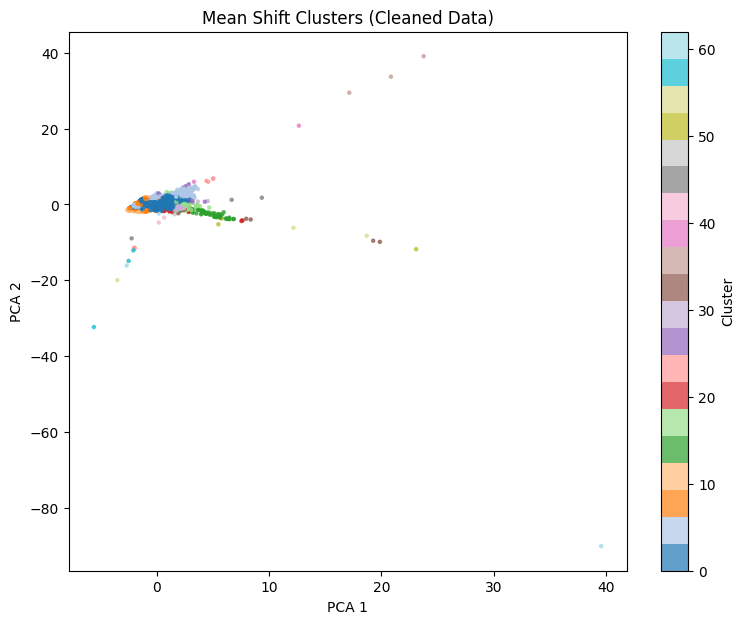

In [34]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_clean = PCA(n_components=2)
X_pca_clean = pca_clean.fit_transform(X_scaled)

plt.figure(figsize=(9,7))

scatter = plt.scatter(
    X_pca_clean[:,0],
    X_pca_clean[:,1],
    c=labels_clean,
    cmap="tab20",
    s=5,
    alpha=0.7
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Mean Shift Clusters (Cleaned Data)")

plt.colorbar(scatter, label="Cluster")

plt.show()


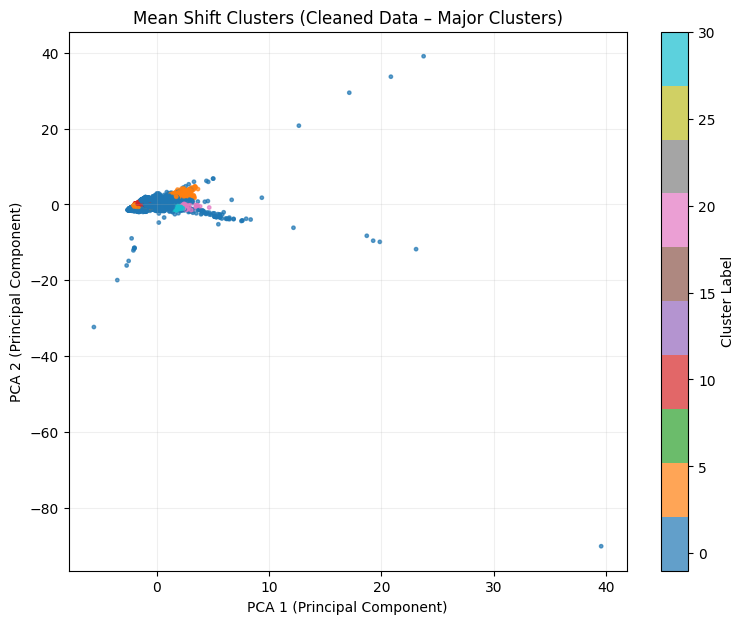

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# identify largest clusters
top_clusters = pd.Series(labels_clean).value_counts().head(8).index

# mark rare clusters
labels_plot = np.where(np.isin(labels_clean, top_clusters), labels_clean, -1)

plt.figure(figsize=(9,7))

scatter = plt.scatter(
    X_pca_clean[:,0],
    X_pca_clean[:,1],
    c=labels_plot,
    cmap="tab10",
    s=6,
    alpha=0.7
)

plt.xlabel("PCA 1 (Principal Component)")
plt.ylabel("PCA 2 (Principal Component)")
plt.title("Mean Shift Clusters (Cleaned Data – Major Clusters)")

plt.colorbar(scatter, label="Cluster Label")
plt.grid(alpha=0.2)

plt.show()

In [36]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="random",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

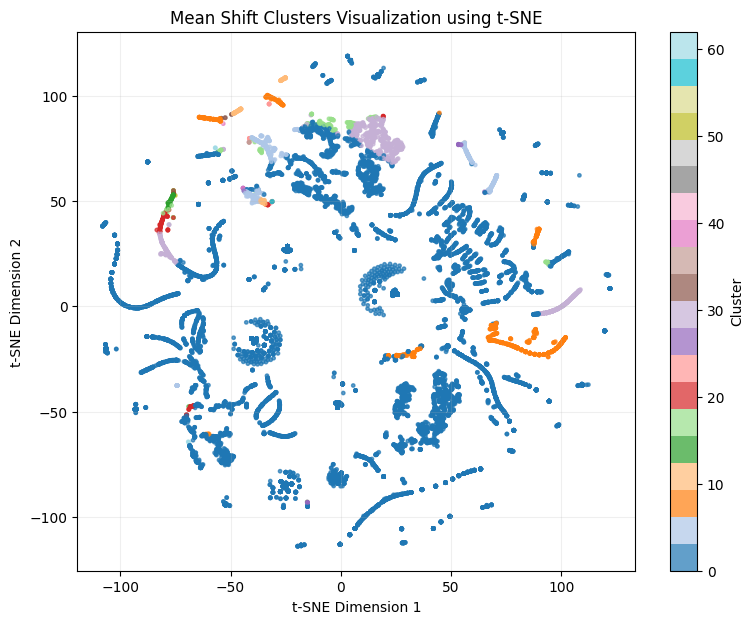

In [37]:
plt.figure(figsize=(9,7))

scatter = plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=labels_clean,
    cmap="tab20",
    s=6,
    alpha=0.7
)

plt.title("Mean Shift Clusters Visualization using t-SNE")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.colorbar(scatter, label="Cluster")

plt.grid(alpha=0.2)

plt.show()

In [38]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# convert to torch tensor
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

dataset = TensorDataset(X_tensor)
loader = DataLoader(dataset, batch_size=256, shuffle=True)

X_tensor.shape

torch.Size([21405, 6])

In [39]:
import torch
from torch import nn

class Autoencoder(nn.Module):
    def __init__(self, input_dim=6, latent_dim=2):
        super().__init__()
        # encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 4),
            nn.ReLU(),
            nn.Linear(4, latent_dim)
        )
        # decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 4),
            nn.ReLU(),
            nn.Linear(4, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

model = Autoencoder(input_dim=6, latent_dim=2)
model

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=6, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=6, bias=True)
  )
)

In [40]:
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 30

loss_history = []

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0
    
    for (batch,) in loader:
        batch = batch.to(device)

        optimizer.zero_grad()
        recon = model(batch)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * batch.size(0)

    epoch_loss /= len(loader.dataset)
    loss_history.append(epoch_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} | Loss: {epoch_loss:.6f}")

Epoch 5/30 | Loss: 0.905629
Epoch 10/30 | Loss: 0.811381
Epoch 15/30 | Loss: 0.732284
Epoch 20/30 | Loss: 0.637536
Epoch 25/30 | Loss: 0.577722
Epoch 30/30 | Loss: 0.550809


In [41]:
import numpy as np

model.eval()

with torch.no_grad():
    Z = model.encoder(X_tensor.to(device)).cpu().numpy()

print("Latent shape:", Z.shape)
print("Latent preview:\n", Z[:5])

Latent shape: (21405, 2)
Latent preview:
 [[-0.30498964  1.3576692 ]
 [-0.69178903  1.5267801 ]
 [-0.30498964  1.3576692 ]
 [-0.69178903  1.5267801 ]
 [ 0.03309618 -0.05939826]]


In [42]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k = 6  # good starting point, we can adjust after seeing the plot
kmeans_latent = KMeans(n_clusters=k, random_state=42, n_init="auto")
latent_labels = kmeans_latent.fit_predict(Z)

print("Clusters:", len(set(latent_labels)))
print("Silhouette (latent KMeans):", silhouette_score(Z, latent_labels))

Clusters: 6
Silhouette (latent KMeans): 0.5496375


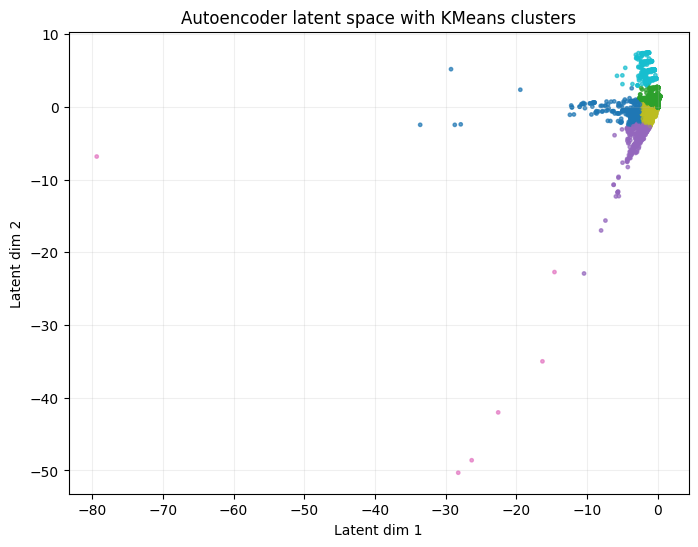

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(Z[:,0], Z[:,1], c=latent_labels, s=6, alpha=0.7, cmap="tab10")
plt.xlabel("Latent dim 1")
plt.ylabel("Latent dim 2")
plt.title("Autoencoder latent space with KMeans clusters")
plt.grid(alpha=0.2)
plt.show()